# Лабораторная работа №3. Понижение размерности
## Задание 1. Геометрия данных в пространстве признаков

Число: 1000 объектов, 5 признаков


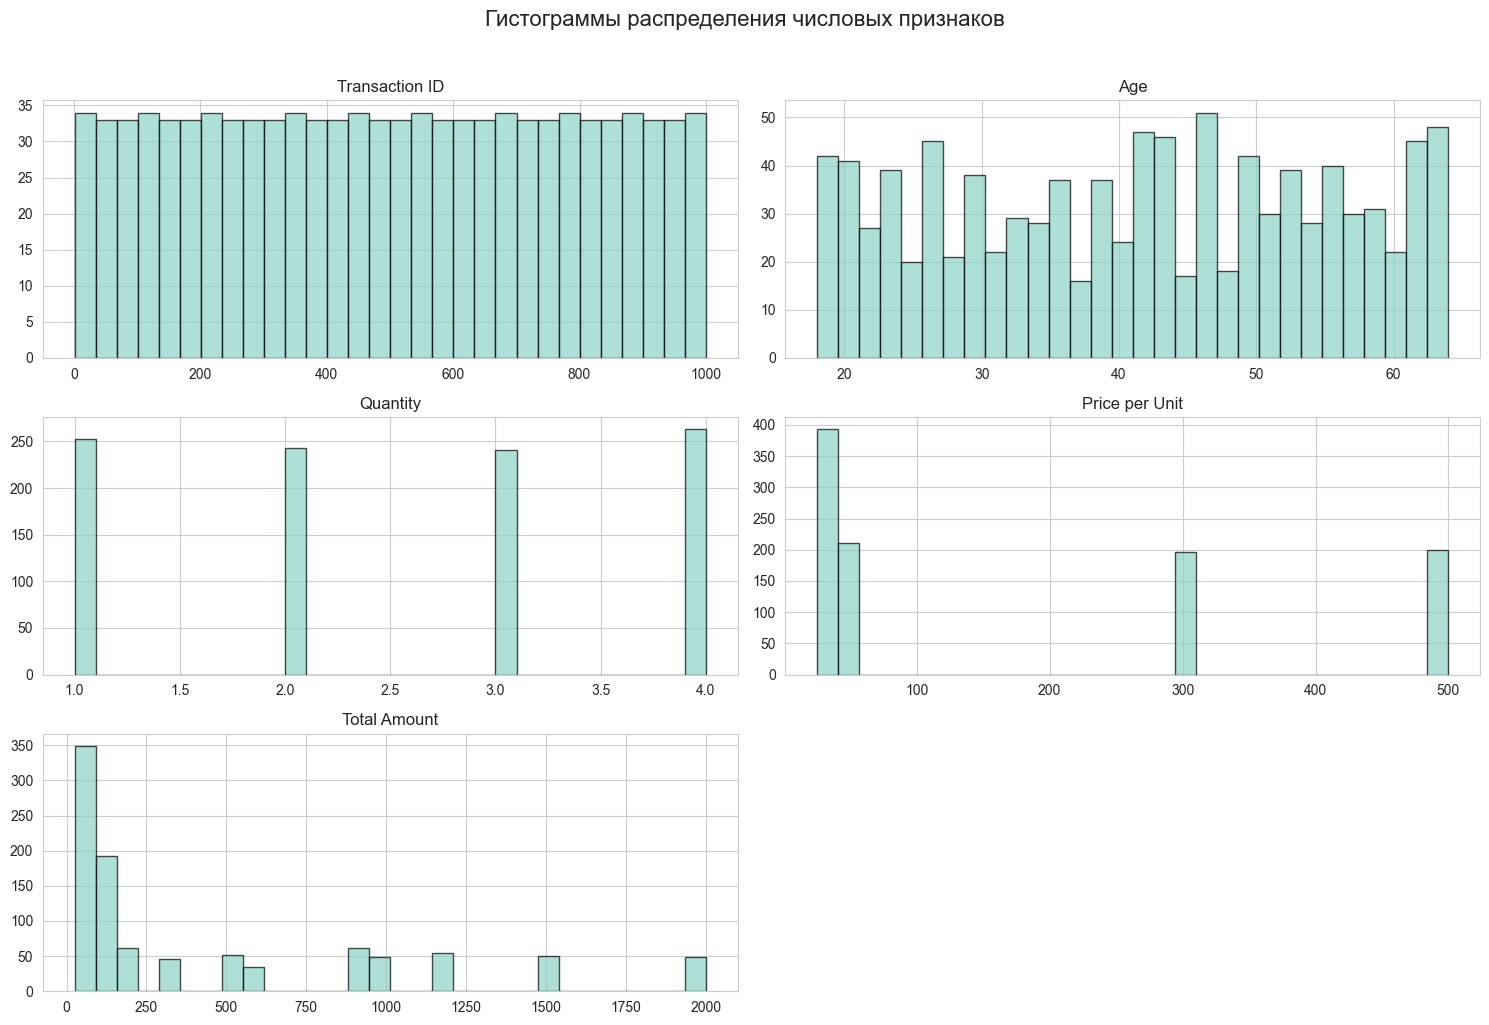

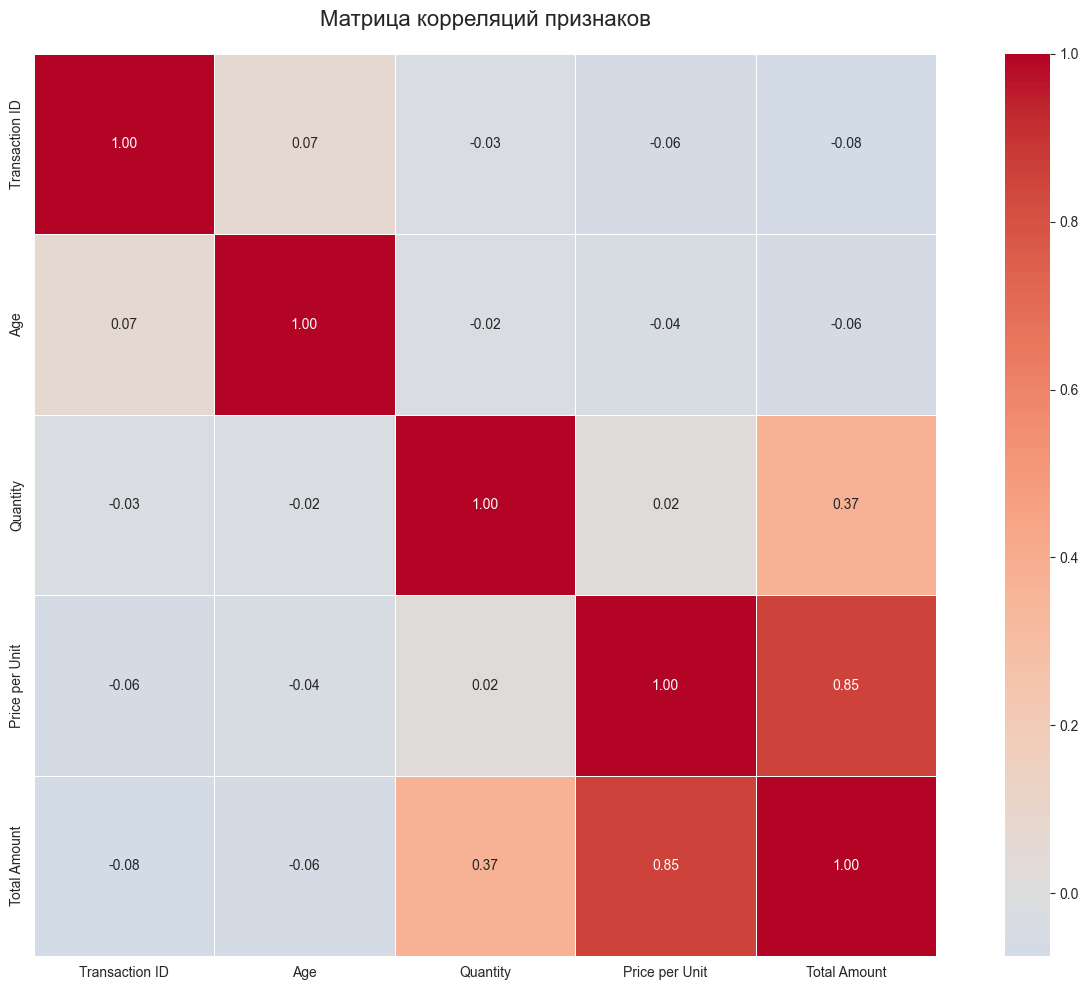

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/retail_sales_dataset.csv')

df_number = df.select_dtypes(include='number')

print(f'Число: {df_number.shape[0]} объектов, {df_number.shape[1]} признаков')
df_number.head()

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

df_number.hist(bins=30, edgecolor='black', alpha=0.7, figsize=(15, 10))
plt.suptitle('Гистограммы распределения числовых признаков', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
corr_matrix = df_number.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Матрица корреляций признаков', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

#### Есть ли сильно коррелированные признаки?
Наиболее сильная связь наблюдается у признака Price per Unit (корреляция 0,85), так как общая сумма сделки на прямую зависит от цены за единицу товара. Второй по силе признак - Quantity (корреляция 0,37), так как вариативность количества товаров часто меньше, чем вариативность цен.
#### Можно ли предположить, что часть признаков содержит избыточную информацию?
Да, можно. Зная Quantity и Price per Unit, можно точно вычислить Total Amount. Следовательно, Total Amount не несет новой уникальной информации, которую нельзя было бы получить из двух других столбцов.

## Задание 2. Реализация PCA

Размер данных: (1000, 4)
Признаки: ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

--- Сравнение реализаций ---
Доля объясненной дисперсии (Scratch): [0.4857 0.2493 0.246  0.019 ]
Доля объясненной дисперсии (Sklearn): [0.4857 0.2493 0.246  0.019 ]

Корреляция 1-й компоненты: 1.0000
Корреляция 2-й компоненты: -1.0000
Реализации эквивалентны, если корреляция близка к 1 или -1.


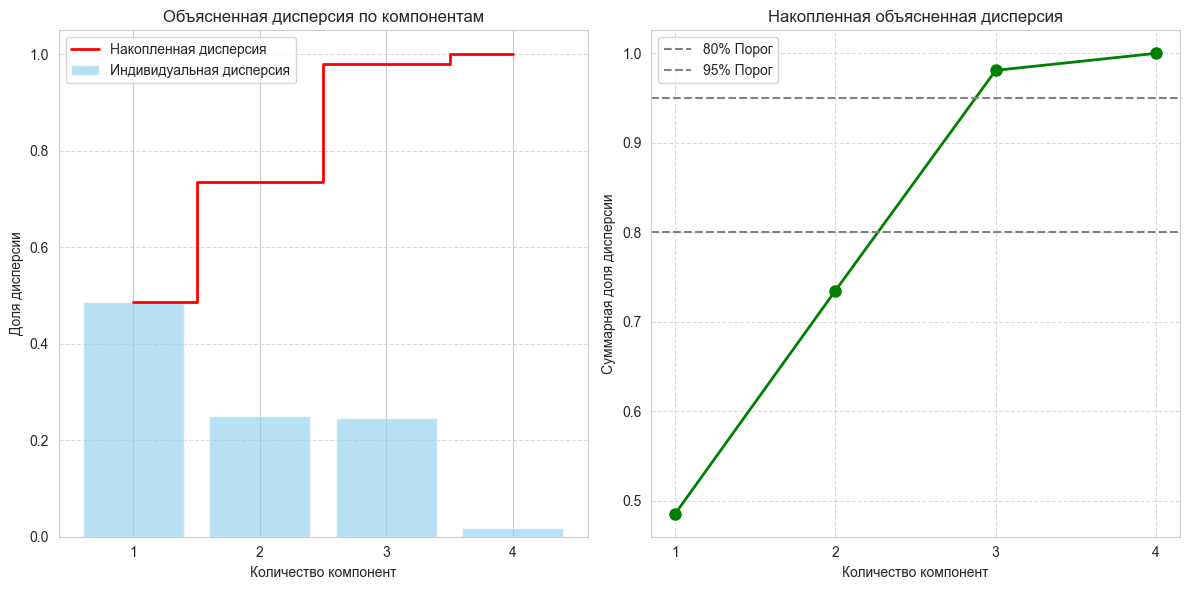

1. Компонент для объяснения 80% дисперсии: 3
   Накопленная дисперсия после 3 компонент: 0.9810
2. Компонент для объяснения 95% дисперсии: 3
   Накопленная дисперсия после 3 компонент: 0.9810


In [2]:
import numpy as np
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
data = df[numeric_cols].values

print(f"Размер данных: {data.shape}")
print(f"Признаки: {numeric_cols}")

class PCAFromScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.std = None
        self.explained_variance_ratio_ = None
        self.eigenvalues = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1
        X_standardized = (X - self.mean) / self.std

        cov_matrix = np.cov(X_standardized, rowvar=False)

        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]

        self.components = eigenvectors[:, :self.n_components]

        total_variance = np.sum(self.eigenvalues)
        self.explained_variance_ratio_ = self.eigenvalues / total_variance

        return self

    def transform(self, X):
        X_standardized = (X - self.mean) / self.std
        X_projected = np.dot(X_standardized, self.components)
        return X_projected

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

n_features = data.shape[1]

pca_scratch = PCAFromScratch(n_components=n_features)
X_pca_scratch = pca_scratch.fit_transform(data)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
pca_sklearn = SklearnPCA(n_components=n_features)
X_pca_sklearn = pca_sklearn.fit_transform(data_scaled)

print("\n--- Сравнение реализаций ---")
print("Доля объясненной дисперсии (Scratch):", np.round(pca_scratch.explained_variance_ratio_, 4))
print("Доля объясненной дисперсии (Sklearn):", np.round(pca_sklearn.explained_variance_ratio_, 4))

corr_p1 = np.corrcoef(X_pca_scratch[:, 0], X_pca_sklearn[:, 0])[0, 1]
corr_p2 = np.corrcoef(X_pca_scratch[:, 1], X_pca_sklearn[:, 1])[0, 1]
print(f"\nКорреляция 1-й компоненты: {corr_p1:.4f}")
print(f"Корреляция 2-й компоненты: {corr_p2:.4f}")
print("Реализации эквивалентны, если корреляция близка к 1 или -1.")

components_range = range(1, n_features + 1)
variance_ratios = pca_scratch.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratios)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(components_range, variance_ratios, alpha=0.6, label='Индивидуальная дисперсия', color='skyblue')
plt.step(components_range, cumulative_variance, where='mid', label='Накопленная дисперсия', color='red', linewidth=2)
plt.xlabel('Количество компонент')
plt.ylabel('Доля дисперсии')
plt.title('Объясненная дисперсия по компонентам')
plt.legend(loc='best')
plt.xticks(components_range)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(components_range, cumulative_variance, 'o-', color='green', linewidth=2, markersize=8)
plt.axhline(y=0.80, color='gray', linestyle='--', label='80% Порог')
plt.axhline(y=0.95, color='gray', linestyle='--', label='95% Порог')
plt.xlabel('Количество компонент')
plt.ylabel('Суммарная доля дисперсии')
plt.title('Накопленная объясненная дисперсия')
plt.legend(loc='best')
plt.xticks(components_range)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

n_comp_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"1. Компонент для объяснения 80% дисперсии: {n_comp_80}")
print(f"   Накопленная дисперсия после {n_comp_80} компонент: {cumulative_variance[n_comp_80-1]:.4f}")

n_comp_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"2. Компонент для объяснения 95% дисперсии: {n_comp_95}")
print(f"   Накопленная дисперсия после {n_comp_95} компонент: {cumulative_variance[n_comp_95-1]:.4f}")

## Задание 3. Интерпретация главных компонент

In [7]:
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
data = df[numeric_cols].values

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca = SklearnPCA(n_components=4)
pca.fit(data_scaled)

components = pca.components_
feature_names = numeric_cols

loadings_df = pd.DataFrame(
    components.T,
    columns=[f'PC{i+1}' for i in range(components.shape[0])],
    index=feature_names
)

print("Коэффициенты признаков в первых 3-х главных компонентах:")
print(loadings_df.iloc[:, :3].round(4))

def analyze_component(pc_index, loadings_df):
    pc_name = f'PC{pc_index + 1}'
    series = loadings_df[pc_name]

    max_abs_idx = series.abs().idxmax()
    max_val = series[max_abs_idx]
    print("\n")
    print(f"--- Анализ {pc_name} ---")
    print(f"Признак с наибольшим вкладом: {max_abs_idx}")
    print(f"Значение коэффициента: {max_val:.4f}")

    sorted_contributions = series.abs().sort_values(ascending=False)
    print("Ранжирование признаков по влиянию :")
    for feat, val in sorted_contributions.items():
        sign = '+' if series[feat] > 0 else '-'
        print(f"  {feat}: {val:.4f} (знак: {sign})")
    print("\n")

for i in range(3):
    analyze_component(i, loadings_df)

Коэффициенты признаков в первых 3-х главных компонентах:
                   PC1     PC2     PC3
Age            -0.0788  0.8755  0.4766
Quantity        0.2925 -0.4145  0.8169
Price per Unit  0.6437  0.2439 -0.3247
Total Amount    0.7028  0.0472  0.0108


--- Анализ PC1 ---
Признак с наибольшим вкладом: Total Amount
Значение коэффициента: 0.7028
Ранжирование признаков по влиянию :
  Total Amount: 0.7028 (знак: +)
  Price per Unit: 0.6437 (знак: +)
  Quantity: 0.2925 (знак: +)
  Age: 0.0788 (знак: -)




--- Анализ PC2 ---
Признак с наибольшим вкладом: Age
Значение коэффициента: 0.8755
Ранжирование признаков по влиянию :
  Age: 0.8755 (знак: +)
  Quantity: 0.4145 (знак: -)
  Price per Unit: 0.2439 (знак: +)
  Total Amount: 0.0472 (знак: +)




--- Анализ PC3 ---
Признак с наибольшим вкладом: Quantity
Значение коэффициента: 0.8169
Ранжирование признаков по влиянию :
  Quantity: 0.8169 (знак: +)
  Age: 0.4766 (знак: +)
  Price per Unit: 0.3247 (знак: -)
  Total Amount: 0.0108 (знак: +)




#### Какие признаки больше всего влияют на первую компоненту?
Больше всего влияет признак Total Amount (0,7028)
#### Можно ли интерпретировать первую компоненту как некоторую комбинацию исходных признаков?
Да, можно:
PC1 = 0,6437*Price per Unit + 0,7028*Total Amount + 0,2925*Quantity - 0,0788*Age
#### Есть ли признаки, которые практически не влияют на первые компоненты?
Есть: Age (-0,0788)

## Задание 4. Визуализация данных

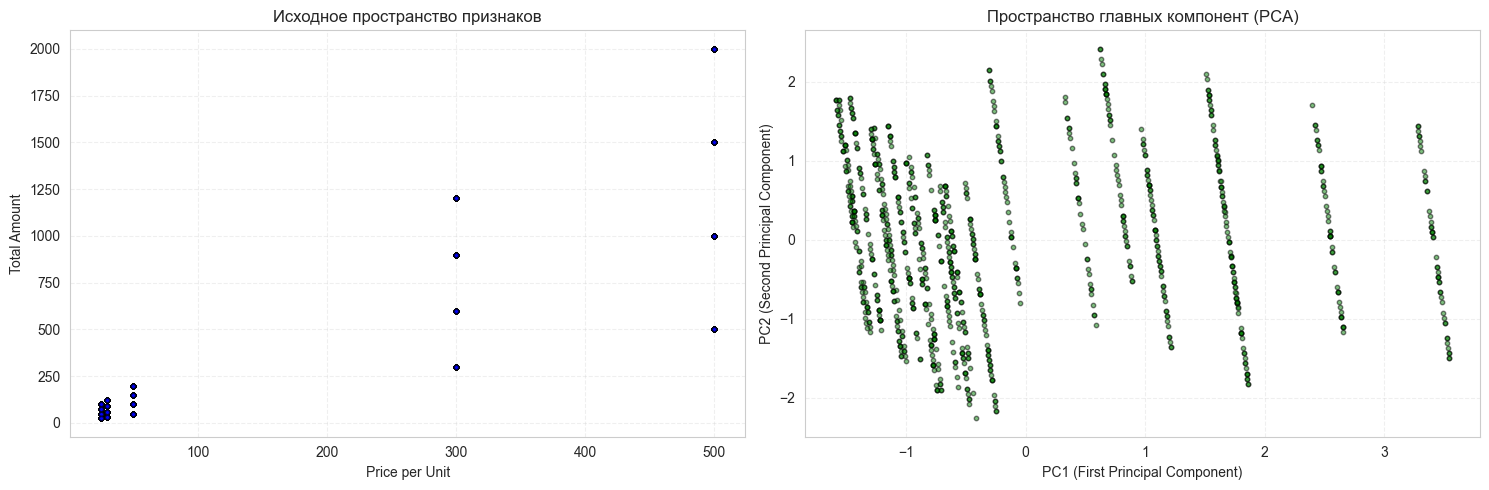

In [12]:
from sklearn.decomposition import PCA
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
data = df[numeric_cols].values

idx_price = numeric_cols.index('Price per Unit')
idx_total = numeric_cols.index('Total Amount')

X_original = data[:, [idx_price, idx_total]]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_scaled)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_original[:, 0], X_original[:, 1], c='blue', alpha=0.3, edgecolors='k', s=10)
plt.xlabel('Price per Unit')
plt.ylabel('Total Amount')
plt.title('Исходное пространство признаков')
plt.grid(True, linestyle='--', alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='green', alpha=0.5, edgecolors='k', s=10)
plt.xlabel('PC1 (First Principal Component)')
plt.ylabel('PC2 (Second Principal Component)')
plt.title('Пространство главных компонент (PCA)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### 1. Улучшилась ли визуализация после PCA?
Да, улучшилась, так как PCA устранил сильную линейную зависимость между признаками (ценой и суммой)
#### 2. Почему в пространстве главных компонент структура может быть заметнее?
Структура заметнее, потому что главные компоненты ортогональны и упорядочены по убыванию дисперсии, что позволяет отделить основной сигнал от шума и устранить искажения, вызванные корреляцией исходных признаков

## Задание 5. Нелинейные методы снижения размерности

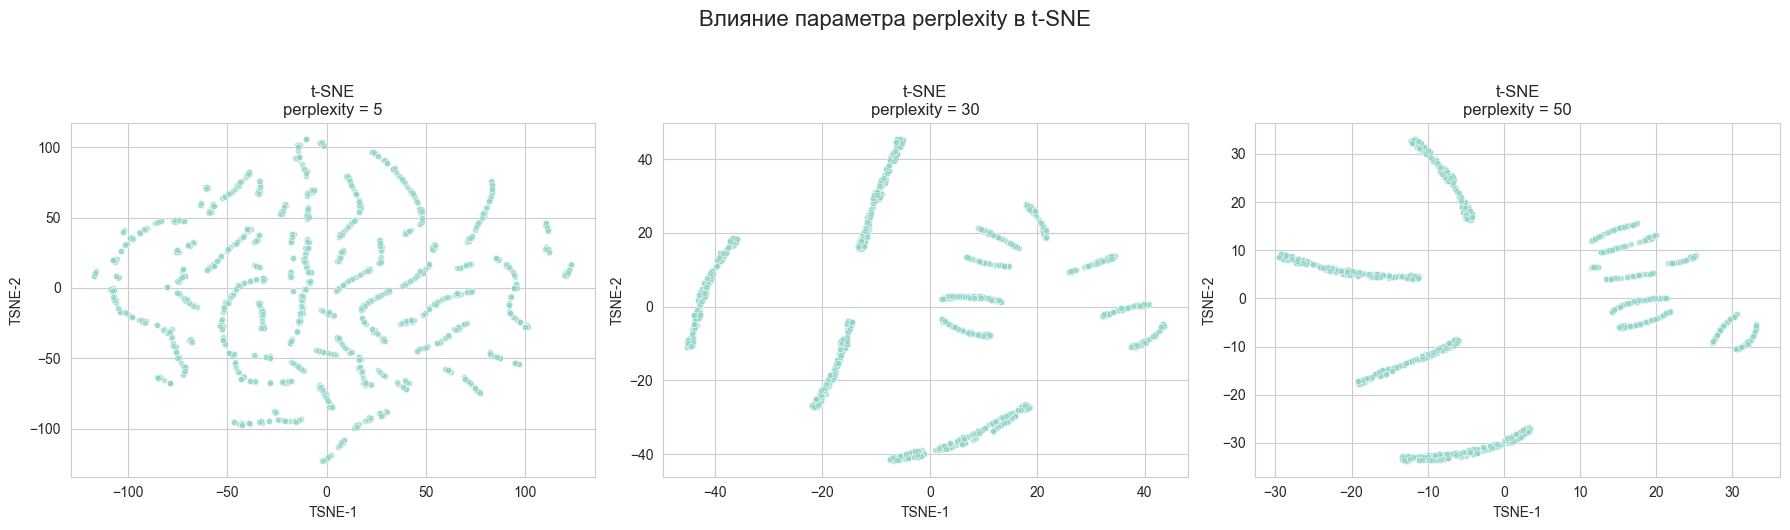

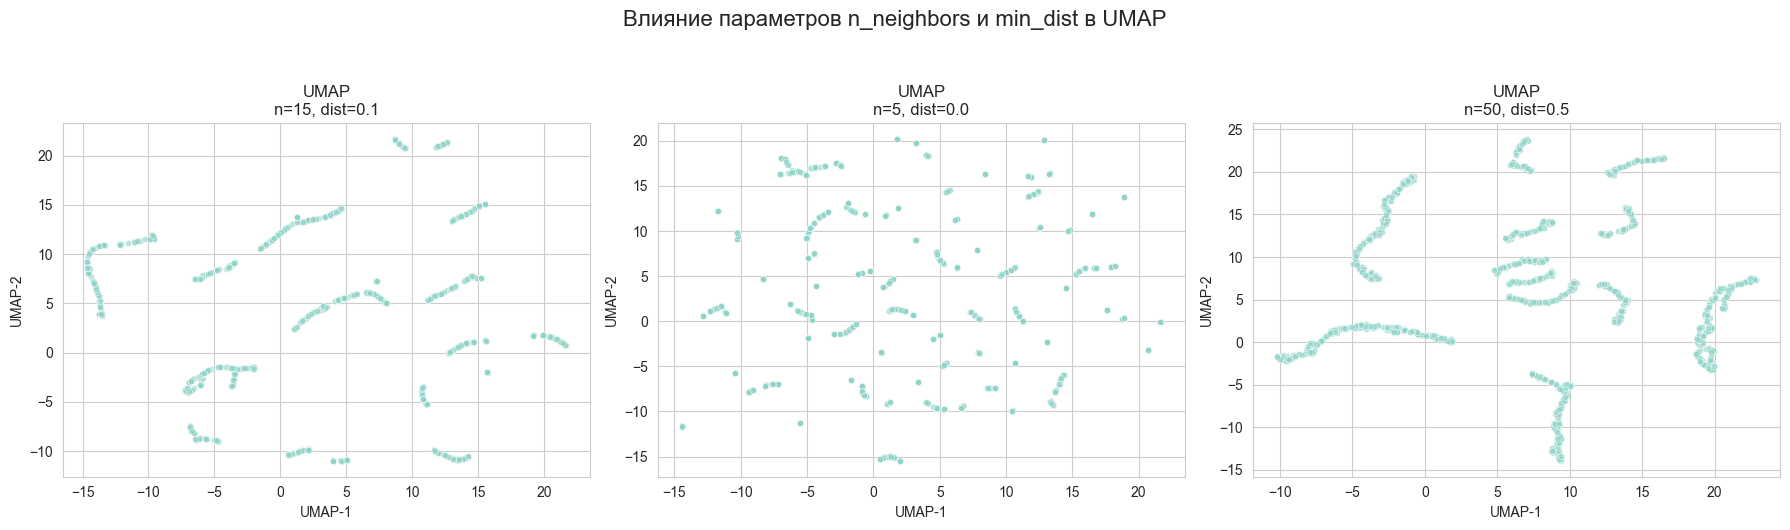

In [16]:
from sklearn.manifold import TSNE
import umap
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="umap")
warnings.filterwarnings("ignore", category=FutureWarning)

numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
df_number = df[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_number)

plt.figure(figsize=(18, 5))
perplexities = [5, 30, 50]

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], alpha=0.6, edgecolor='w', linewidth=0.5, s=20)
    plt.title(f't-SNE\nperplexity = {p}')
    plt.xlabel('TSNE-1')
    plt.ylabel('TSNE-2')

plt.suptitle('Влияние параметра perplexity в t-SNE', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 5))

configs = [
    {"n_neighbors": 15, "min_dist": 0.1},
    {"n_neighbors": 5, "min_dist": 0.0},
    {"n_neighbors": 50, "min_dist": 0.5}
]

for i, cfg in enumerate(configs):
    mapper = umap.UMAP(
        n_neighbors=cfg['n_neighbors'],
        min_dist=cfg['min_dist'],
        random_state=42
    )
    X_umap = mapper.fit_transform(X_scaled)

    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], alpha=0.6, edgecolor='w', linewidth=0.5, s=20)
    title = f"UMAP\nn={cfg['n_neighbors']}, dist={cfg['min_dist']}"
    plt.title(title)
    plt.xlabel('UMAP-1')
    plt.ylabel('UMAP-2')

plt.suptitle('Влияние параметров n_neighbors и min_dist в UMAP', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

#### 1. Как меняется структура данных при разных параметрах?
t-SNE:
1. perplexity = 5: Данные разбиваются на множество мелких, изолированных кластеров, алгоритм фокусируется только на ближайших соседях
2. perplexity = 30: Кластеры становятся крупнее и более связными.
3. perplexity = 50: Лучше видна общая форма облака данных, взаимосвязь между крупными группами.

UMAP:
- n=15, dist=0.1: Умеренно плотные кластеры, хорошо разделены. Сохраняется как локальная, так и глобальная структура.
- n=5, dist=0.0: Очень плотные, четко разделенные микрокластеры. Глобальная структура теряется — кластеры разбросаны хаотично.
- n=50, dist=0.5: Кластеры становятся более разреженными и растянутыми. Лучше видна общая топология: как группы связаны между собой в пространстве.
#### 2. Какой метод даёт наиболее интерпретируемую визуализацию?
UMAP, так как он лучше сохраняет глобальную структуру данных и расстояния между кластерами, делая взаимное расположение групп более осмысленным и устойчивым к изменению параметров, чем t-SNE.
#### 3. Почему результаты разных методов могут существенно отличаться?
Потому что t-SNE работает со статистикой: он преобразует расстояния между точками в вероятности и стремится минимизировать расхождение между распределениями соседей в исходном и новом пространствах. UMAP же опирается на топологию данных: он представляет датасет как граф связности и проецирует его на плоскость, стараясь максимально сохранить структуру этого графа.

## Задание 6. Исследование степени сжатия данных

Используемые признаки: ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
Данные: 1000 объектов, 4 признаков

PCA: СНИЖЕНИЕ РАЗМЕРНОСТИ И ВОССТАНОВЛЕНИЕ
k= 1 | MSE=0.514324 | Дисперсия=48.57%
k= 2 | MSE=0.265007 | Дисперсия=73.50%
k= 3 | MSE=0.018977 | Дисперсия=98.10%
k= 4 | MSE=0.000000 | Дисперсия=100.00%


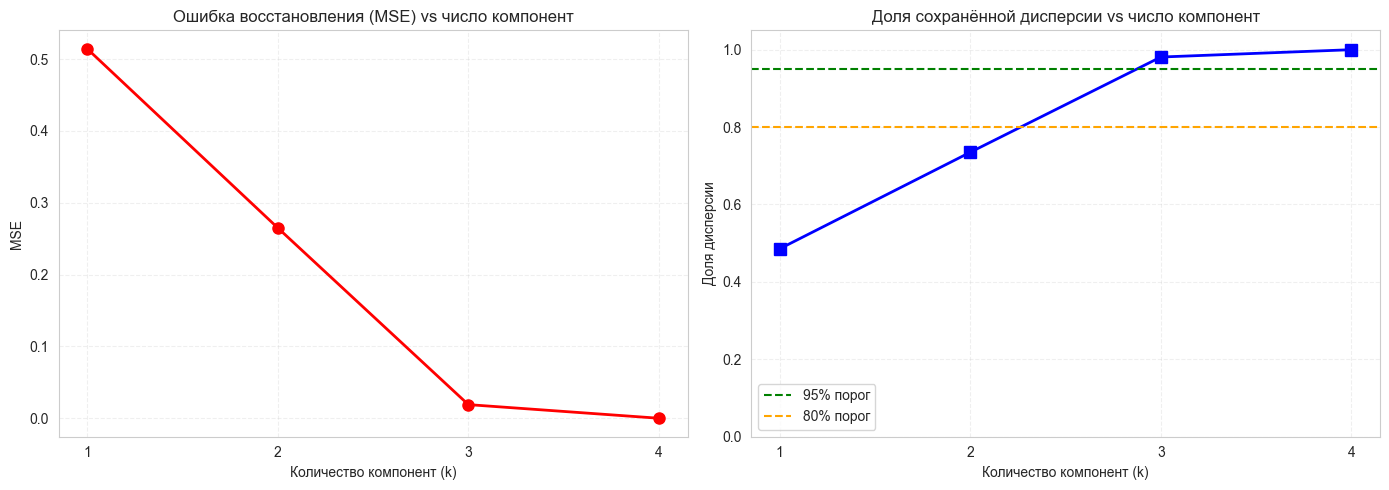


Таблица результатов:
 Число компонент (k) Ошибка восстановления (MSE) Сохранённая дисперсия (%)
                   1                    0.514324                     48.57
                   2                    0.265007                     73.50
                   3                    0.018977                     98.10
                   4                    0.000000                    100.00

Уменьшение ошибки при добавлении компонент:
  k=1 → k=2: ΔMSE = 0.249317
  k=2 → k=3: ΔMSE = 0.246030
  k=3 → k=4: ΔMSE = 0.018977


In [17]:
from sklearn.metrics import mean_squared_error

df_number = df.select_dtypes(include='number')

if 'Transaction ID' in df_number.columns:
    df_number = df_number.drop(columns=['Transaction ID'])

feature_names = df_number.columns.tolist()
print(f"Используемые признаки: {feature_names}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_number)

n_features = X_scaled.shape[1]
n_samples = X_scaled.shape[0]
print(f"Данные: {n_samples} объектов, {n_features} признаков")

k_values = [k for k in range(1, n_features + 1)]
results = {}

print("\nPCA: СНИЖЕНИЕ РАЗМЕРНОСТИ И ВОССТАНОВЛЕНИЕ")

for k in k_values:
    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X_scaled)

    X_reconstructed = pca.inverse_transform(X_reduced)

    mse = mean_squared_error(X_scaled, X_reconstructed)

    variance_retained = np.sum(pca.explained_variance_ratio_)

    results[k] = {
        'pca': pca,
        'X_reduced': X_reduced,
        'X_reconstructed': X_reconstructed,
        'mse': mse,
        'variance_retained': variance_retained
    }

    print(f"k={k:2d} | MSE={mse:.6f} | Дисперсия={variance_retained*100:5.2f}%")

mse_values = [results[k]['mse'] for k in k_values]
variance_values = [results[k]['variance_retained'] for k in k_values]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, mse_values, marker='o', linestyle='-', color='red', linewidth=2, markersize=8)
plt.title('Ошибка восстановления (MSE) vs число компонент')
plt.xlabel('Количество компонент (k)')
plt.ylabel('MSE')
plt.xticks(k_values)
plt.grid(True, alpha=0.3, linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(k_values, variance_values, marker='s', linestyle='-', color='blue', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='green', linestyle='--', label='95% порог')
plt.axhline(y=0.80, color='orange', linestyle='--', label='80% порог')
plt.title('Доля сохранённой дисперсии vs число компонент')
plt.xlabel('Количество компонент (k)')
plt.ylabel('Доля дисперсии')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({
    'Число компонент (k)': k_values,
    'Ошибка восстановления (MSE)': [f"{results[k]['mse']:.6f}" for k in k_values],
    'Сохранённая дисперсия (%)': [f"{results[k]['variance_retained']*100:.2f}" for k in k_values]
})

print("\nТаблица результатов:")
print(summary_df.to_string(index=False))

if len(mse_values) >= 2:
    mse_diffs = np.diff(mse_values)
    print("\nУменьшение ошибки при добавлении компонент:")
    for i in range(len(k_values)-1):
        print(f"  k={k_values[i]} → k={k_values[i+1]}: ΔMSE = {abs(mse_diffs[i]):.6f}")

#### Анализ формы данных
##### Как быстро уменьшается ошибка:
Ошибка уменьшается очень быстро на начальном этапе. График имеет форму крутого спуска в начале. Наибольшая эффективность снижения размерности достигается именно на первых двух шагах.
##### Есть ли точка, после которой уменьшение ошибки становится незначительным:
Да, такая точка есть - это k = 3. После неё уменьшение ошибки становится пренебрежимо малым.
### 6.5 Интерпретация результатов
1. Почему при малом числе компонент ошибка восстановления большая?
- Малое число компонент отбрасывает значительную часть вариативности данных, не способствуя адекватному описанию структуры.
2. Почему увеличение числа компонент уменьшает ошибку?
-  Каждая новая компонента захватывает следующий по важности источник разброса данных, улучшая аппроксимацию.
3. Можно ли полностью восстановить исходные данные при использовании всех компонент?
- При k=N (число исходных признаков) преобразование становится обратимым без потерь.
4. Как это связано с объяснённой дисперсией PCA?
- Ошибка восстановления равна сумме дисперсий отброшенных компонент; чем выше объясненная дисперсия оставленных, тем ниже ошибка.
5. Как можно определить разумное число компонент, при котором данные уже хорошо описаны, но размерность существенно меньше?
- Метод локтя или порог дисперсии: Выбирают минимальное k, после которого кривая ошибки выполаживается («локоть») или накопленная дисперсия достигает целевого уровня (например, 95%).

## Задание 7. Итоговый анализ
1. Какую роль играет снижение размерности в анализе данных?
- Снижение размерности упрощает данные, удаляет шум и избыточность, ускоряет вычисления и позволяет визуализировать многомерные структуры в 2D/3D.
2. Всегда ли уменьшение размерности полезно?
-  Нет. Если потеряна критически важная информация или структура данных слишком сложна для выбранного метода, качество моделей может ухудшиться.
3. В каких случаях линейные методы могут работать хуже нелинейных?
- Линейные методы хуже работают, когда данные лежат на нелинейном многообразии (например, имеют форму сложных кластеров), так как они не могут сохранить локальные расстояния при глобальной проекции.
4. Какие преимущества и ограничения есть у методов PCA, t-SNE и UMAP?

| Метод  | Тип         | Преимущества                                                                                                          | Ограничения                                                                                                                                              |
|:-------|:------------|:----------------------------------------------------------------------------------------------------------------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------|
| PCA    | Линейный    | Быстрый и масштабируемый.<br>Интерпретируемость.<br>Сохраняет глобальную структуру.<br>Обратимое преобразование.      | Только линейные зависимости.<br> Чувствителен к масштабу.<br>Плохо подходит для визуализации сложных кластеров                                           |
| t-SNE  | Нелинейный  | Отлично выявляет локальные кластеры.<br>Учитывает вероятностное сходство.<br>Хорошо работает с многомерными данными.  | Медленный и ресурсоёмкий — сложность O(N²).<br>Не сохраняет глобальную структуру.<br>Стохастический(нужно фиксировать random_state)                      |
| UMAP   | Нелинейный  | Быстрее t-SNE.<br>Сохраняет как локальную, так и глобальную структуру.<br>Стабильнее t-SNE.                           | Сложнее интерпретировать.<br>Требует настройки гиперпараметров.<br>Может искажать плотность — при малом min_dist кластеры становятся слишком компактными |
